# Strength Analysis Workflow — CTETRA Solid Elements

This notebook demonstrates a standard strength screening workflow using the `op2_native` library.

**file:** `cylinder-0001.op2` — two subcases (AXIAL_LOAD, FIXED–AXIAL)  
**element type:** CTETRA solid elements (`solid_stresses`)  
**element subset:** 100 elements (EIDs 1057 – 1156)  
**material allowable:** F_tu = 40 (model units — adjust to match your material)

---
**Steps**
1. Load the OP2  
2. Inspect available results  
3. Extract the element subset  
4. Compute element-level VM stress envelope (max across integration nodes)  
5. Screen — compute margins of safety  
6. Visualize — VM stress distribution and sorted bar chart  
7. Summary report  


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from op2_native.reader import OP2

pd.set_option("display.float_format", "{:.4g}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


## 1 · Load the OP2


In [2]:
OP2_FILE = Path("run_files/model/cylinder-0001.op2")
op2 = OP2(OP2_FILE)
print(f"Loaded: {OP2_FILE}")


Loaded: run_files\model\cylinder-0001.op2


## 2 · Inspect Available Results


In [3]:
solid  = op2.solid_stresses()
bar    = op2.bar_stresses()
forces = op2.element_forces()
disps  = op2.displacements()

summary = pd.DataFrame({
    "result":   ["solid_stresses", "bar_stresses", "element_forces", "displacements"],
    "subcases": [sorted(solid.keys()), sorted(bar.keys()),
                 sorted(forces.keys()), sorted(disps.keys())],
    "rows_sc1": [len(solid.get(1, [])), len(bar.get(1, [])),
                 len(forces.get(1, [])), len(disps.get(1, []))],
})
print(summary.to_string(index=False))


        result subcases  rows_sc1
solid_stresses   [1, 2]     19432
  bar_stresses   [1, 2]       832
element_forces   [1, 2]       832
 displacements   [1, 2]      8102


In [4]:
df_all = solid[1]

print("Solid stress columns :", list(df_all.columns))
print(f"Total rows            : {len(df_all):,}")
print(f"Unique element IDs    : {df_all['EID'].nunique():,}")
print(f"EID range             : {df_all['EID'].min()} – {df_all['EID'].max()}")
print(f"Nodes per element     : {df_all.groupby('EID').size().value_counts().to_dict()}")
print(f"\nVM stress  min = {df_all['VM'].min():.4g}  max = {df_all['VM'].max():.4g}  [model units]")
df_all.head(8)


Solid stress columns : ['EID', 'GRID', 'SX', 'SY', 'SZ', 'SXY', 'SYZ', 'SZX', 'VM']
Total rows            : 19,432
Unique element IDs    : 4,858
EID range             : 1057 – 5914
Nodes per element     : {4: 4858}

VM stress  min = 0.5036  max = 35.57  [model units]


,EID,GRID,SX,SY,SZ,SXY,SYZ,SZX,VM
0,1057,529,1.041,0.7081,6.141,-0.0651,-1.214,-0.06583,5.68
1,1057,530,1.399,1.529,5.84,-0.1203,-0.9459,0.1653,4.688
2,1057,531,0.5173,0.1255,5.975,-0.1135,-0.6838,0.1372,5.794
3,1057,532,1.423,2.072,6.629,0.04211,-1.497,0.1667,5.564
4,1058,447,3.231,4.421,10.33,-0.1784,-2.233,0.4129,7.677
5,1058,530,1.127,1.208,5.423,0.03645,-0.9978,0.5046,4.676
6,1058,532,1.08,1.929,6.04,-0.09476,-1.487,0.2958,5.294
7,1058,533,1.332,1.865,7.387,-0.1463,-1.299,0.05519,6.233


## 3 · Extract the Element Subset

Select a contiguous block of 100 CTETRA elements (EIDs 1057 – 1156) to represent a region of interest.  
Change `EID_START` to select a different region.


In [5]:
EID_START   = 1057
EID_END     = EID_START + 199      # inclusive → 100 elements
ELEMENT_SET = list(range(EID_START, EID_END + 1))

# Pull both subcases filtered to the element set
subsets = {
    sc: df[df["EID"].isin(ELEMENT_SET)].copy()
    for sc, df in solid.items()
}

for sc, df in subsets.items():
    n_elem = df["EID"].nunique()
    print(f"  Subcase {sc}: {n_elem} elements, {len(df)} node-rows  "
          f"| VM  min={df['VM'].min():.4g}  max={df['VM'].max():.4g}")


  Subcase 1: 200 elements, 800 node-rows  | VM  min=0.5329  max=33.29
  Subcase 2: 200 elements, 800 node-rows  | VM  min=5.334  max=68.79


## 4 · Element-Level VM Stress (max across integration nodes)

Each CTETRA has 4 integration nodes. We take the **maximum VM across all nodes** as the bounding value for the element.


In [6]:
def element_vm_max(df: pd.DataFrame) -> pd.DataFrame:
    """Return one row per element containing the node with maximum VM stress."""
    idx = df.groupby("EID")["VM"].idxmax()
    return df.loc[idx].reset_index(drop=True)

vm_max = {sc: element_vm_max(df) for sc, df in subsets.items()}

print("Top 10 worst elements — Subcase 1 (sorted by VM descending):")
print(vm_max[1].sort_values("VM", ascending=False).head(10).to_string(index=False))


Top 10 worst elements — Subcase 1 (sorted by VM descending):
 EID  GRID      SX    SY    SZ     SXY    SYZ    SZX    VM
1153   346   8.611 8.314 26.39  0.7531 -14.82 -6.492 33.29
1151   346    5.75 7.305 22.14   1.178 -11.56 -8.245 29.23
1194   347   7.202 7.436 19.78 -0.0374 -8.302 -10.62 26.47
1196   347   4.957 4.282 18.32   1.534 -6.634 -10.85 26.08
1195   346 -0.8958 3.709 3.865   1.911 -12.65 -2.109 22.95
1128   338   3.731 6.647 6.105   1.916  10.78  6.377 22.11
1185   340   5.509 2.704 5.271   1.473  5.605   11.1 21.86
1133   344  0.8772 5.464 5.962  -0.762 -11.88   1.47 21.34
1088   346   2.853 4.373 6.241   2.206 -8.994 -6.862 20.18
1084   231   5.823  6.63  20.8   2.024 -3.282  4.648 17.95


## 5 · Margin of Safety

$$MS = \frac{F_{tu}}{RF \times \sigma_{VM}} - 1$$

Adjust `F_TU` (ultimate allowable) and `RF` (reserve factor / load factor) to match your project requirements.


In [7]:
# ── Allowables and load factor ───────────────────────────────────────────────
F_TY = 48.0    # yield stress allowable   [model units]
F_TU = 60.0    # ultimate stress allowable [model units]
RF   = 1.25    # reserve factor (limit load → ultimate load)

# Consistent reference-line spec used across all stress plots.
# Tuple: (stress value, label, color, linestyle, linewidth)
ALLOWABLE_LINES = [
    (F_TU / RF, "Limit", "crimson",  "--", 1.5),   # effective ult. limit at limit load
    (F_TY,      "Fty",   "#2ca02c",  ":",  1.5),   # yield allowable
    (F_TU,      "Ftu",   "darkred",  "-",  1.5),   # ultimate allowable
]

def draw_allowables(ax, orientation: str = "h") -> None:
    """Add Limit / Fty / Ftu reference lines to *ax*.
    orientation='h' → axhline (stress on y-axis)
    orientation='v' → axvline (stress on x-axis)
    """
    fn = ax.axhline if orientation == "h" else ax.axvline
    for val, lbl, color, ls, lw in ALLOWABLE_LINES:
        fn(val, color=color, linestyle=ls, linewidth=lw, label=f"{lbl} = {val:.1f}")

def add_ms(df: pd.DataFrame) -> pd.DataFrame:
    """Add MS_ult, MS_yield, MS (governing) and CRITICAL columns."""
    df = df.copy()
    df["VM_factored"] = df["VM"] * RF                    # VM at ultimate load
    df["MS_ult"]      = F_TU / df["VM_factored"] - 1.0  # ultimate margin
    df["MS_yield"]    = F_TY / df["VM"]          - 1.0  # yield margin (at limit load)
    df["MS"]          = df[["MS_ult", "MS_yield"]].min(axis=1)  # governing
    df["CRITICAL"]    = df["MS"] < 0.0
    return df

screened = {sc: add_ms(df) for sc, df in vm_max.items()}

for sc, df in screened.items():
    n_u = int((df["MS_ult"]   < 0).sum())
    n_y = int((df["MS_yield"] < 0).sum())
    n_c = int(df["CRITICAL"].sum())
    print(f"  SC {sc}: {n_c}/{len(df)} failed  "
          f"(ult: {n_u}, yield: {n_y}  |  "
          f"MS_ult min={df['MS_ult'].min():.4f}  "
          f"MS_yield min={df['MS_yield'].min():.4f})")


  SC 1: 0/200 failed  (ult: 0, yield: 0  |  MS_ult min=0.4418  MS_yield min=0.4418)
  SC 2: 11/200 failed  (ult: 11, yield: 11  |  MS_ult min=-0.3022  MS_yield min=-0.3022)


## 6 · Visualize

### 6a · VM Stress Distribution


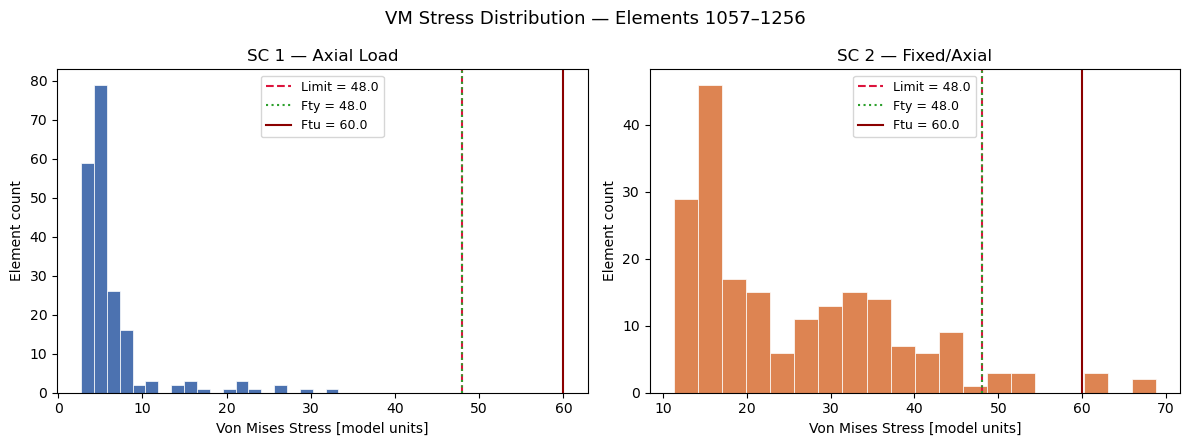

In [8]:
sc_labels = {1: "SC 1 — Axial Load", 2: "SC 2 — Fixed/Axial"}
colors    = {1: "#4C72B0", 2: "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
fig.suptitle(
    f"VM Stress Distribution — Elements {EID_START}–{EID_END}",
    fontsize=13,
)

for ax, (sc, df) in zip(axes, screened.items()):
    ax.hist(df["VM"].values, bins=20, color=colors[sc],
            edgecolor="white", linewidth=0.5, zorder=2)
    draw_allowables(ax, orientation="v")
    ax.set_title(sc_labels.get(sc, f"SC {sc}"))
    ax.set_xlabel("Von Mises Stress [model units]")
    ax.set_ylabel("Element count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 6b · Sorted Envelope Bar Chart


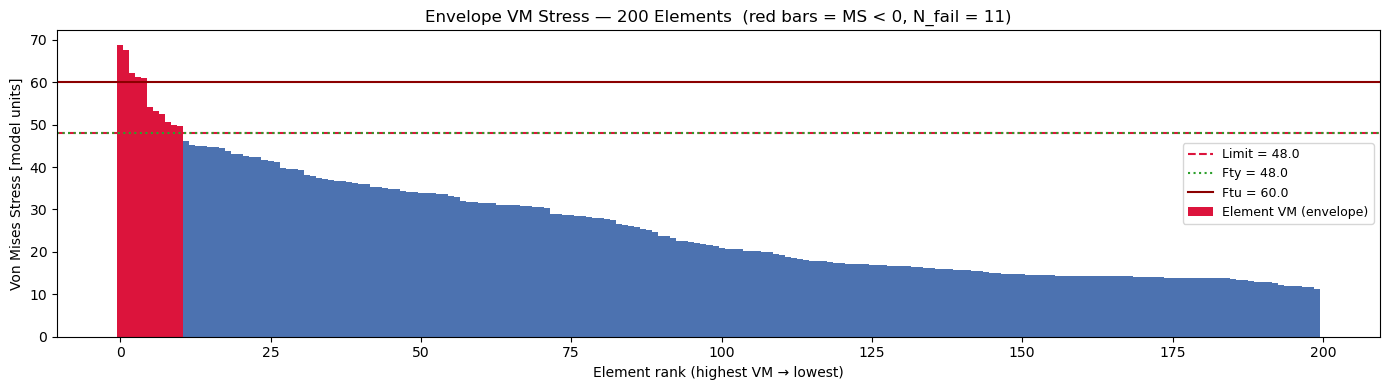

In [9]:
# ── Envelope: worst case per element across all subcases ─────────────────────
envelope = (
    pd.concat([df.assign(SC=sc) for sc, df in screened.items()])
    .sort_values("VM", ascending=False)
    .groupby("EID", as_index=False)
    .first()
    .sort_values("VM", ascending=False)
    .reset_index(drop=True)
)

bar_colors = ["crimson" if c else "#4C72B0" for c in envelope["CRITICAL"]]

fig2, ax2 = plt.subplots(figsize=(14, 4))
ax2.bar(range(len(envelope)), envelope["VM"], color=bar_colors, width=1.0,
        edgecolor="none", zorder=2, label="Element VM (envelope)")
draw_allowables(ax2, orientation="h")
ax2.set_xlabel("Element rank (highest VM → lowest)")
ax2.set_ylabel("Von Mises Stress [model units]")
ax2.set_title(
    f"Envelope VM Stress — {len(envelope)} Elements  "
    f"(red bars = MS < 0, N_fail = {envelope['CRITICAL'].sum()})",
    fontsize=12,
)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 6c · Margin of Safety Waterfall

Each bar is an element's governing margin of safety — the minimum of the ultimate
(`MS_ult`) and yield (`MS_yield`) checks. Green = positive margin (pass), red = negative (fail).
The 8 worst elements are annotated with their EID.


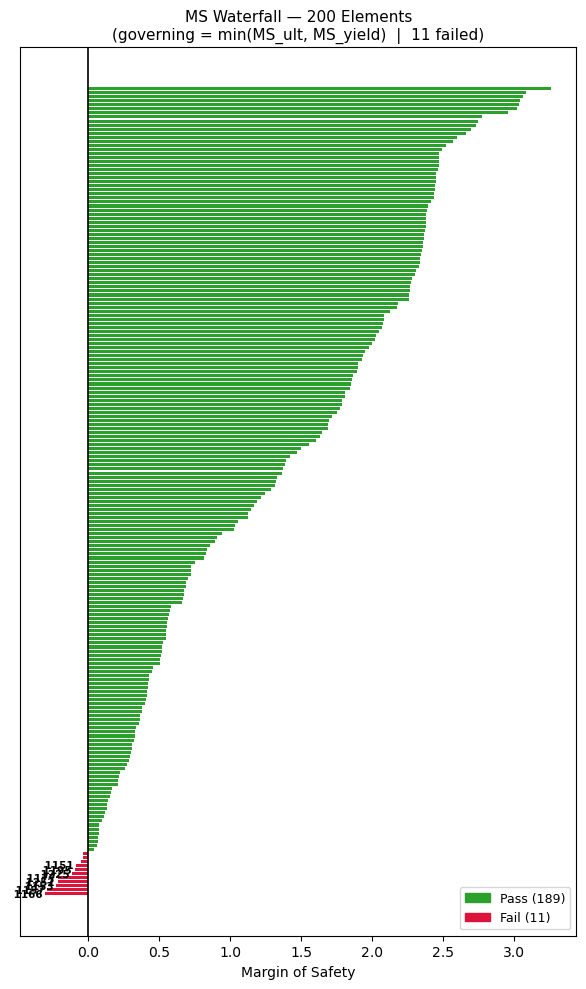

In [10]:
ms_waterfall = (
    envelope[["EID", "MS", "MS_ult", "MS_yield", "CRITICAL"]]
    .sort_values("MS")
    .reset_index(drop=True)
)

PASS_COLOR = "#2ca02c"
FAIL_COLOR = "crimson"
w_colors = [FAIL_COLOR if c else PASS_COLOR for c in ms_waterfall["CRITICAL"]]

fig, ax = plt.subplots(figsize=(6, 10))
y = np.arange(len(ms_waterfall))
ax.barh(y, ms_waterfall["MS"], color=w_colors, height=0.75, edgecolor="none")
ax.axvline(0, color="black", linewidth=1.2, zorder=3)

# Annotate worst 8 with EID
for rank in range(min(8, len(ms_waterfall))):
    row = ms_waterfall.iloc[rank]
    x_pos = min(row["MS"], 0) - 0.02
    ax.text(x_pos, rank, f" {int(row['EID'])}", va="center", ha="right",
            fontsize=7.5, color="black", fontweight="bold")

ax.set_yticks([])
ax.set_xlabel("Margin of Safety")
ax.set_title(
    f"MS Waterfall — {len(ms_waterfall)} Elements\n"
    f"(governing = min(MS_ult, MS_yield)  |  "
    f"{ms_waterfall['CRITICAL'].sum()} failed)",
    fontsize=11,
)

from matplotlib.patches import Patch
n_fail = int(ms_waterfall["CRITICAL"].sum())
n_pass = len(ms_waterfall) - n_fail
ax.legend(
    handles=[Patch(color=PASS_COLOR, label=f"Pass ({n_pass})"),
             Patch(color=FAIL_COLOR, label=f"Fail ({n_fail})")],
    fontsize=9, loc="lower right",
)
plt.tight_layout()
plt.show()


### 6d · Stress Components — Worst Elements

Normal stress components (SX, SY, SZ) and Von Mises at the max-VM integration node
for the 12 worst-margin elements (SC 1). Allowable reference lines apply to individual
components; signed values can individually exceed them while VM remains below the limit.


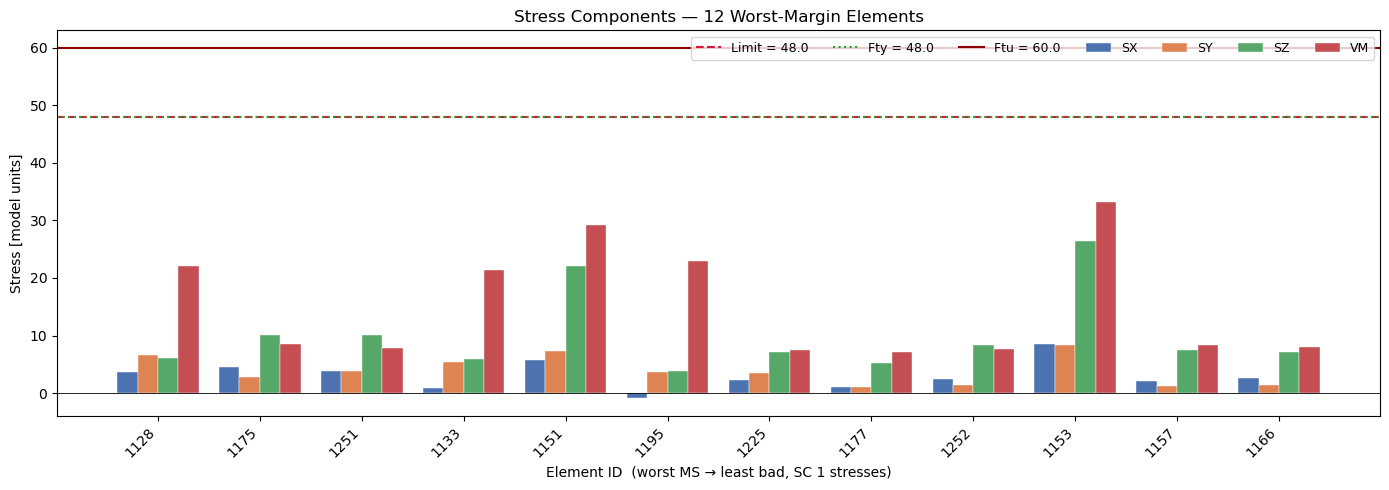

In [11]:
N_WORST = 12
worst_eids = ms_waterfall.head(N_WORST)["EID"].astype(int).tolist()

comp_df = (
    subsets[1][subsets[1]["EID"].isin(worst_eids)]
    .pipe(element_vm_max)
    .set_index("EID")
    .reindex(worst_eids[::-1])   # reverse: worst at left of plot
)

stress_cols = ["SX", "SY", "SZ", "VM"]
palette     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

x  = np.arange(N_WORST)
ww = 0.20

fig, ax = plt.subplots(figsize=(14, 5))
for j, (col, color) in enumerate(zip(stress_cols, palette)):
    offsets = x + (j - 1.5) * ww
    ax.bar(offsets, comp_df[col].values, width=ww, color=color, label=col,
           edgecolor="white", linewidth=0.3, zorder=2)

draw_allowables(ax, orientation="h")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels([str(e) for e in worst_eids[::-1]], rotation=45, ha="right")
ax.set_xlabel(f"Element ID  (worst MS → least bad, SC 1 stresses)")
ax.set_ylabel("Stress [model units]")
ax.set_title(f"Stress Components — {N_WORST} Worst-Margin Elements", fontsize=12)
ax.legend(fontsize=9, ncol=7, loc="upper right")
plt.tight_layout()
plt.show()


### 6e · Subcase VM Comparison

Per-element VM scatter between the two subcases. Points above the 45° diagonal are
governed by SC 2; points below by SC 1. Allowable reference lines are drawn on both
axes — elements in the upper-right quadrant beyond any line are the most critical.


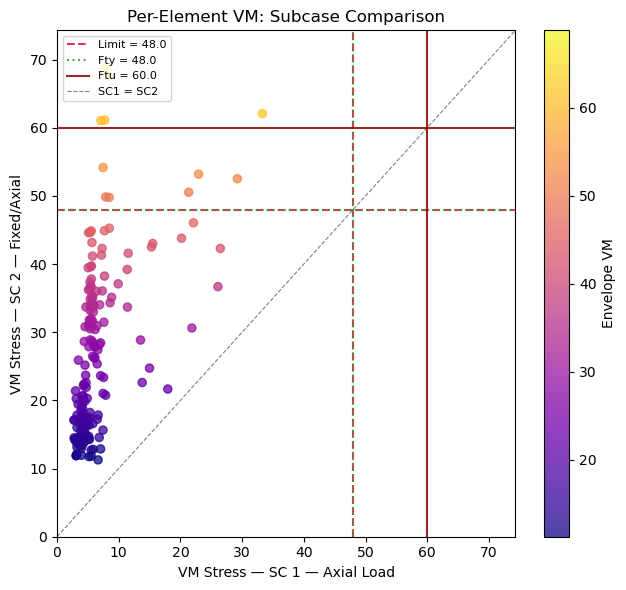

In [12]:
sc_list = sorted(vm_max.keys())
sc_a, sc_b = sc_list[0], sc_list[1]

col_a = f"VM_sc{sc_a}"
col_b = f"VM_sc{sc_b}"

merged = (
    vm_max[sc_a][["EID", "VM"]].rename(columns={"VM": col_a})
    .merge(vm_max[sc_b][["EID", "VM"]].rename(columns={"VM": col_b}), on="EID")
)

mvm = merged[[col_a, col_b]].max(axis=1)
lim = mvm.max() * 1.08

fig, ax = plt.subplots(figsize=(6.5, 6))
sc_pts = ax.scatter(merged[col_a], merged[col_b], c=mvm, cmap="plasma",
                    s=35, alpha=0.75, zorder=3)
cbar = plt.colorbar(sc_pts, ax=ax)
cbar.set_label("Envelope VM")

for val, lbl, color, ls, lw in ALLOWABLE_LINES:
    ax.axvline(val, color=color, linestyle=ls, linewidth=lw, alpha=0.85)
    ax.axhline(val, color=color, linestyle=ls, linewidth=lw, alpha=0.85,
               label=f"{lbl} = {val:.1f}")

ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5, label="SC1 = SC2")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel(f"VM Stress — {sc_labels.get(sc_a, f'SC {sc_a}')}")
ax.set_ylabel(f"VM Stress — {sc_labels.get(sc_b, f'SC {sc_b}')}")
ax.set_title("Per-Element VM: Subcase Comparison", fontsize=12)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


### 6f · Von Mises Failure Envelope — Principal Stress Space

Each element's stress state is projected onto the **σ₁–σ₂ principal stress plane**.

**Why do failures appear inside the ellipse?** The dashed ellipses drawn in the top panels
assume σ₃ = 0 (plane-stress). For CTETRA solid elements σ₃ is non-zero. The full 3-D
Von Mises criterion at fixed σ₃ is still an ellipse in the σ₁–σ₂ plane, but it is:

- **Centered at (σ₃, σ₃)** — shifts into the third quadrant when σ₃ is compressive
- **Scaled by r = √(F²−σ₃²)** — shrinks as |σ₃| grows

$$(\sigma_1-\sigma_3)^2 - (\sigma_1-\sigma_3)(\sigma_2-\sigma_3) + (\sigma_2-\sigma_3)^2 = F^2 - \sigma_3^2$$

When σ₃ is large and compressive, the corrected Ftu ellipse can be much smaller than the
displayed σ₃=0 reference — elements that look safe in the 2-D projection really are outside
the actual 3-D boundary. The bottom panel shows this explicitly for SC 2.


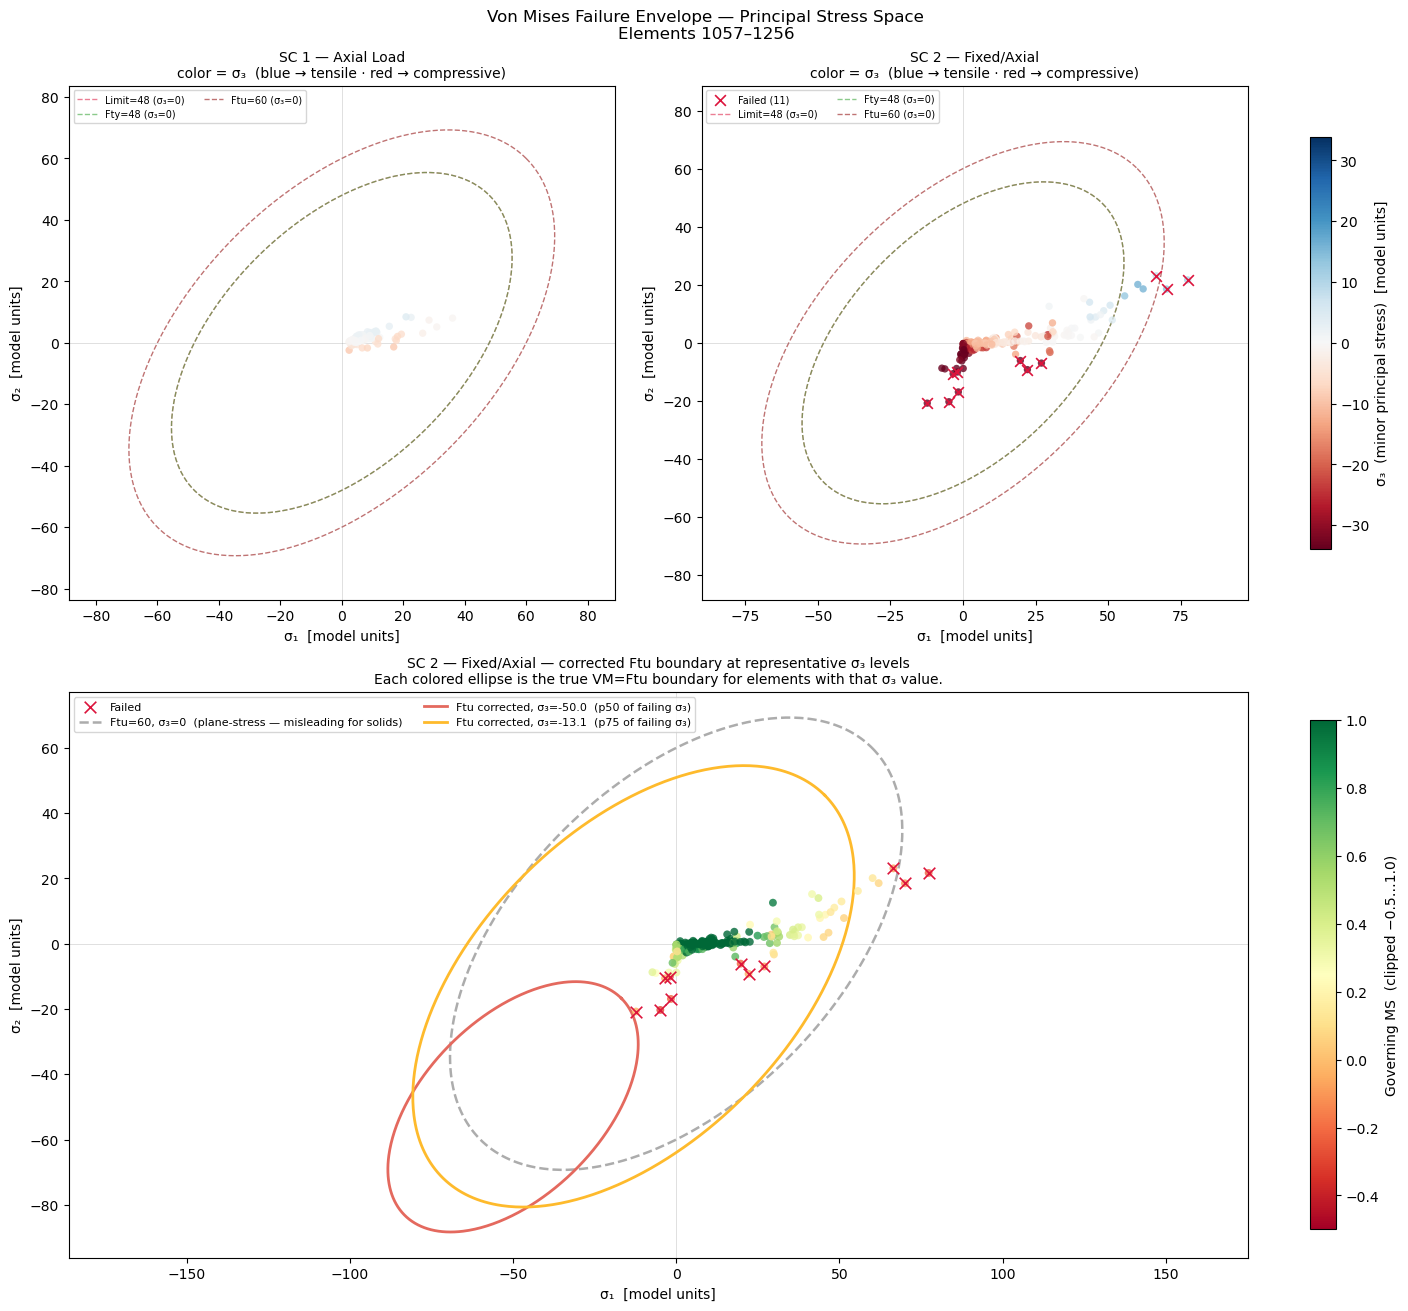

In [13]:
# ── Compute principal stresses from the full 3-D stress tensor ───────────────
def principal_stresses(df: pd.DataFrame) -> pd.DataFrame:
    """Add S1 ≥ S2 ≥ S3 (principal) columns via eigenvalues of [σ] at each row."""
    n = len(df)
    T = np.zeros((n, 3, 3))
    T[:, 0, 0] = df["SX"].values
    T[:, 1, 1] = df["SY"].values
    T[:, 2, 2] = df["SZ"].values
    T[:, 0, 1] = T[:, 1, 0] = df["SXY"].values
    T[:, 1, 2] = T[:, 2, 1] = df["SYZ"].values
    T[:, 0, 2] = T[:, 2, 0] = df["SZX"].values
    eigs = np.linalg.eigvalsh(T)[:, ::-1]   # (N,3), sorted σ₁ ≥ σ₂ ≥ σ₃
    out = df.copy()
    out["S1"], out["S2"], out["S3"] = eigs[:, 0], eigs[:, 1], eigs[:, 2]
    return out

def vm_ellipse(F: float, s3: float = 0.0):
    """Exact VM boundary in σ₁–σ₂ space at fixed σ₃.

    At fixed σ₃ the Von Mises criterion simplifies to an ellipse:
        (σ₁-σ₃)² - (σ₁-σ₃)(σ₂-σ₃) + (σ₂-σ₃)² = F² - σ₃²
    Centered at (σ₃, σ₃), radius r = √(F²-σ₃²).
    Returns (None, None) when |σ₃| ≥ F (criterion already violated).
    """
    r2 = F**2 - s3**2
    if r2 <= 0:
        return None, None
    r = np.sqrt(r2)
    t = np.linspace(0, 2 * np.pi, 500)
    s1 = s3 + r * np.cos(t) + (r / np.sqrt(3)) * np.sin(t)
    s2 = s3 + r * np.cos(t) - (r / np.sqrt(3)) * np.sin(t)
    return s1, s2

# ── Assemble per-subcase DataFrame ───────────────────────────────────────────
ps = {
    sc: (
        principal_stresses(element_vm_max(subsets[sc]))
        .merge(screened[sc][["EID", "MS", "CRITICAL"]], on="EID")
    )
    for sc in sorted(screened)
}

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 13), constrained_layout=True)
fig.suptitle(
    f"Von Mises Failure Envelope — Principal Stress Space\n"
    f"Elements {EID_START}–{EID_END}",
    fontsize=12,
)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_sc1  = fig.add_subplot(gs[0, 0])
ax_sc2  = fig.add_subplot(gs[0, 1])
ax_bott = fig.add_subplot(gs[1, :])

# ── Top panels: both subcases, colored by σ₃ ─────────────────────────────────
all_s3  = np.concatenate([df["S3"].values for df in ps.values()])
s3_lim  = np.percentile(np.abs(all_s3), 95)
cmap_s3 = plt.cm.RdBu
norm_s3 = plt.Normalize(-s3_lim, s3_lim)

for ax, (sc, df) in zip([ax_sc1, ax_sc2], ps.items()):
    ax.scatter(df["S1"], df["S2"], c=df["S3"], cmap=cmap_s3, norm=norm_s3,
               s=28, alpha=0.80, zorder=4, linewidths=0)

    fail = df[df["CRITICAL"]]
    if len(fail):
        ax.scatter(fail["S1"], fail["S2"], s=60, marker="x",
                   color="crimson", linewidths=1.2, zorder=5,
                   label=f"Failed ({len(fail)})")

    # σ₃=0 plane-stress reference ellipses (faded dashed)
    for F_val, lbl, col, ls, lw in ALLOWABLE_LINES:
        s1e, s2e = vm_ellipse(F_val, s3=0.0)
        ax.plot(s1e, s2e, color=col, linestyle="--", linewidth=1.0, alpha=0.55,
                label=f"{lbl}={F_val:.0f} (σ₃=0)")

    ax.axhline(0, color="grey", linewidth=0.5, alpha=0.35)
    ax.axvline(0, color="grey", linewidth=0.5, alpha=0.35)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("σ₁  [model units]")
    ax.set_ylabel("σ₂  [model units]")
    ax.set_title(
        f"{sc_labels.get(sc, f'SC {sc}')}\n"
        "color = σ₃  (blue → tensile · red → compressive)",
        fontsize=10,
    )
    ax.legend(fontsize=7, loc="upper left", ncol=2)

fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_s3, norm=norm_s3),
    ax=[ax_sc1, ax_sc2], shrink=0.80,
    label="σ₃  (minor principal stress)  [model units]",
)

# ── Bottom panel: SC 2 with corrected Ftu ellipses ───────────────────────────
sc2_key = sorted(ps.keys())[1]
sc2_df  = ps[sc2_key]
fail2   = sc2_df[sc2_df["CRITICAL"]]

cmap_ms_b = plt.cm.RdYlGn
norm_ms_b = plt.Normalize(-0.5, 1.0)

ax_bott.scatter(sc2_df["S1"], sc2_df["S2"],
                c=sc2_df["MS"].clip(-0.5, 1.0), cmap=cmap_ms_b, norm=norm_ms_b,
                s=32, alpha=0.80, zorder=4, linewidths=0)
ax_bott.scatter(fail2["S1"], fail2["S2"], s=70, marker="x",
                color="crimson", linewidths=1.2, zorder=5, label="Failed")

# σ₃=0 plane-stress Ftu boundary (grey dashed — what was shown before)
s1r, s2r = vm_ellipse(F_TU, s3=0.0)
ax_bott.plot(s1r, s2r, color="grey", linestyle="--", linewidth=1.8,
             alpha=0.65, label=f"Ftu={F_TU:.0f}, σ₃=0  (plane-stress — misleading for solids)")

# Corrected Ftu ellipses at representative percentiles of the failing σ₃ values
pcts   = [10, 25, 50, 75]
pal    = plt.cm.plasma(np.linspace(0.15, 0.85, len(pcts)))
for pct, col in zip(pcts, pal):
    s3_rep = np.percentile(fail2["S3"].values, pct)
    s1c, s2c = vm_ellipse(F_TU, s3=s3_rep)
    if s1c is not None:
        ax_bott.plot(s1c, s2c, color=col, linewidth=2.0, zorder=3,
                     label=f"Ftu corrected, σ₃={s3_rep:.1f}  (p{pct} of failing σ₃)")

ax_bott.axhline(0, color="grey", linewidth=0.5, alpha=0.35)
ax_bott.axvline(0, color="grey", linewidth=0.5, alpha=0.35)
ax_bott.set_aspect("equal", adjustable="datalim")
ax_bott.set_xlabel("σ₁  [model units]")
ax_bott.set_ylabel("σ₂  [model units]")
ax_bott.set_title(
    f"{sc_labels.get(sc2_key, f'SC {sc2_key}')} — corrected Ftu boundary at representative σ₃ levels\n"
    "Each colored ellipse is the true VM=Ftu boundary for elements with that σ₃ value.",
    fontsize=10,
)
ax_bott.legend(fontsize=8, loc="upper left", ncol=2)
fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_ms_b, norm=norm_ms_b),
    ax=ax_bott, shrink=0.90,
    label="Governing MS  (clipped −0.5…1.0)",
)
plt.show()


### 6g · Von Mises Cylinder — 3D Principal Stress Space

The Von Mises criterion is a **cylinder** in (σ₁, σ₂, σ₃) space whose axis is the
hydrostatic direction (1, 1, 1). Radius = F√(2/3). The 2D ellipses in §6f are simply
cross-sections of this cylinder at fixed σ₃. Points outside the cylinder fail regardless
of where they appear in any 2D projection — this is why SC 2 shows failures that look
inside the plane-stress ellipse.


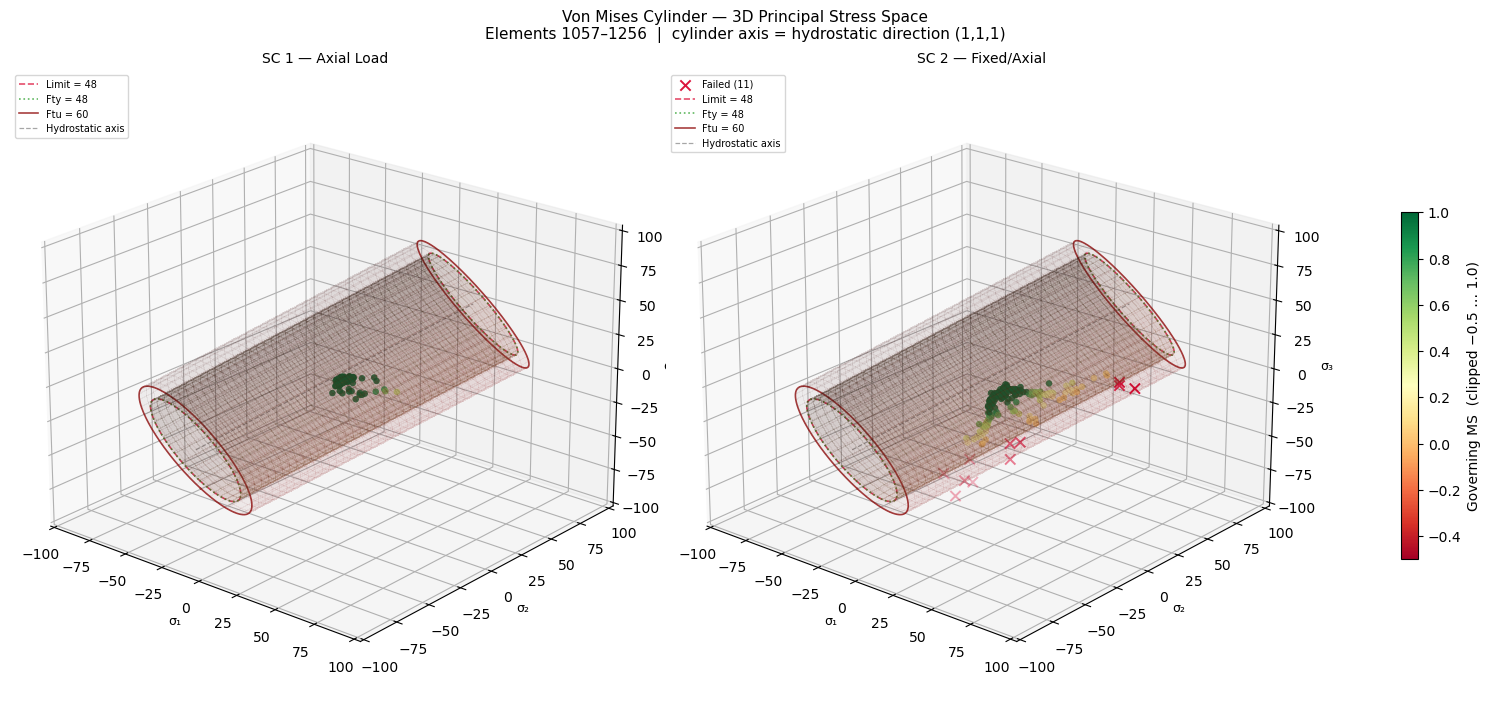

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — activates 3-D projection

# ── VM cylinder helpers ───────────────────────────────────────────────────────
# Von Mises: (σ₁-σ₂)²+(σ₂-σ₃)²+(σ₃-σ₁)² = 2F²  → cylinder, axis ∥ (1,1,1)

def _vm_cyl(F, t_lo, t_hi, nt=40, ntheta=80):
    """Surface mesh of the Von Mises cylinder between hydrostatic coords t_lo..t_hi."""
    R  = F * np.sqrt(2.0 / 3.0)
    h  = np.array([1,  1,  1]) / np.sqrt(3)
    e1 = np.array([1, -1,  0]) / np.sqrt(2)
    e2 = np.array([1,  1, -2]) / np.sqrt(6)
    T, TH = np.meshgrid(np.linspace(t_lo, t_hi, nt),
                         np.linspace(0, 2 * np.pi, ntheta))
    X = T*h[0] + R*np.cos(TH)*e1[0] + R*np.sin(TH)*e2[0]
    Y = T*h[1] + R*np.cos(TH)*e1[1] + R*np.sin(TH)*e2[1]
    Z = T*h[2] + R*np.cos(TH)*e1[2] + R*np.sin(TH)*e2[2]
    return X, Y, Z

def _vm_ring(F, t_val, ntheta=200):
    """One circular cross-section of the VM cylinder at hydrostatic coordinate t_val."""
    R  = F * np.sqrt(2.0 / 3.0)
    h  = np.array([1,  1,  1]) / np.sqrt(3)
    e1 = np.array([1, -1,  0]) / np.sqrt(2)
    e2 = np.array([1,  1, -2]) / np.sqrt(6)
    th = np.linspace(0, 2 * np.pi, ntheta)
    x = t_val*h[0] + R*np.cos(th)*e1[0] + R*np.sin(th)*e2[0]
    y = t_val*h[1] + R*np.cos(th)*e1[1] + R*np.sin(th)*e2[1]
    z = t_val*h[2] + R*np.cos(th)*e1[2] + R*np.sin(th)*e2[2]
    return x, y, z

# ── Principal stresses (reuses principal_stresses() defined in §6f) ───────────
ps3d = {
    sc: (
        principal_stresses(element_vm_max(subsets[sc]))
        .merge(screened[sc][["EID", "MS", "CRITICAL"]], on="EID")
    )
    for sc in sorted(screened)
}

all_pts   = pd.concat(ps3d.values(), ignore_index=True)
hydro_all = (all_pts["S1"] + all_pts["S2"] + all_pts["S3"]) / np.sqrt(3)
pad       = (hydro_all.max() - hydro_all.min()) * 0.20
t_lo, t_hi = hydro_all.min() - pad, hydro_all.max() + pad

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap_3d = plt.cm.RdYlGn
norm_3d = plt.Normalize(-0.5, 1.0)

fig = plt.figure(figsize=(15, 7), layout="constrained")
fig.suptitle(
    f"Von Mises Cylinder — 3D Principal Stress Space\n"
    f"Elements {EID_START}–{EID_END}  |  cylinder axis = hydrostatic direction (1,1,1)",
    fontsize=11,
)

surf_alphas = [0.09, 0.06, 0.05]   # Limit, Fty, Ftu

for idx, (sc, df) in enumerate(ps3d.items()):
    ax3 = fig.add_subplot(1, 2, idx + 1, projection="3d")

    pass_ = df[~df["CRITICAL"]]
    fail  = df[df["CRITICAL"]]

    # Element scatter — colored by governing MS
    ax3.scatter(pass_["S1"], pass_["S2"], pass_["S3"],
                c=pass_["MS"].clip(-0.5, 1.0), cmap=cmap_3d, norm=norm_3d,
                s=22, alpha=0.85, depthshade=True, linewidths=0, zorder=4)
    if len(fail):
        ax3.scatter(fail["S1"], fail["S2"], fail["S3"],
                    s=55, marker="x", color="crimson", linewidths=1.4,
                    zorder=5, label=f"Failed ({len(fail)})")

    # VM cylinder for each allowable level
    for (F_val, lbl, col, ls, lw), surf_a in zip(ALLOWABLE_LINES, surf_alphas):
        Xs, Ys, Zs = _vm_cyl(F_val, t_lo, t_hi)
        ax3.plot_surface(Xs, Ys, Zs, color=col, alpha=surf_a,
                         linewidth=0, antialiased=False)
        for t_edge in [t_lo, t_hi]:
            rx, ry, rz = _vm_ring(F_val, t_edge)
            ax3.plot(rx, ry, rz, color=col, linestyle=ls,
                     linewidth=lw * 0.8, alpha=0.75,
                     label=f"{lbl} = {F_val:.0f}" if t_edge == t_lo else "")

    # Hydrostatic axis
    hax = np.outer(np.linspace(t_lo, t_hi, 60), np.array([1, 1, 1]) / np.sqrt(3))
    ax3.plot(hax[:, 0], hax[:, 1], hax[:, 2],
             "k--", lw=0.9, alpha=0.35, label="Hydrostatic axis")

    ax3.set_xlabel("σ₁", fontsize=9, labelpad=1)
    ax3.set_ylabel("σ₂", fontsize=9, labelpad=1)
    ax3.set_zlabel("σ₃", fontsize=9, labelpad=1)
    ax3.set_title(sc_labels.get(sc, f"SC {sc}"), fontsize=10, pad=6)
    ax3.legend(fontsize=7, loc="upper left", ncol=1)
    ax3.view_init(elev=22, azim=-50)

fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_3d, norm=norm_3d),
    ax=fig.axes, shrink=0.55, pad=0.08,
    label="Governing MS  (clipped −0.5 … 1.0)",
)
plt.show()


### 6h · Stress Exceedance (CCDF)

The Complementary Cumulative Distribution Function answers: **what fraction of elements
exceed each stress level?** Useful for weight-optimisation conversations — a steep drop
near the allowable means most elements are lightly loaded with a few hot spots driving
the design.


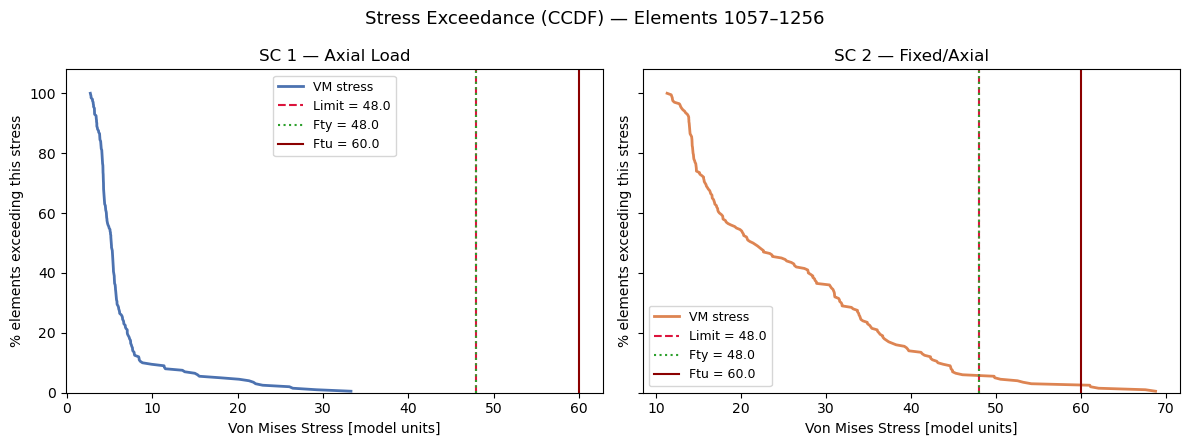

In [15]:
fig_h, axes_h = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig_h.suptitle(
    f"Stress Exceedance (CCDF) — Elements {EID_START}–{EID_END}",
    fontsize=13,
)

for ax, (sc, df) in zip(axes_h, screened.items()):
    vm_s = np.sort(df["VM"].values)[::-1]
    pct  = np.arange(1, len(vm_s) + 1) / len(vm_s) * 100
    ax.plot(vm_s, pct, color=colors[sc], linewidth=2.0, label="VM stress")
    draw_allowables(ax, orientation="v")
    ax.set_title(sc_labels.get(sc, f"SC {sc}"))
    ax.set_xlabel("Von Mises Stress [model units]")
    ax.set_ylabel("% elements exceeding this stress")
    ax.set_ylim(0, 108)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 6i · Parallel Coordinates

One line per element; axes are the six stress components and VM. Lines are colored by
governing MS, so you can immediately see which component combinations co-occur in the
worst elements. Each axis is independently normalized 0–1 so magnitudes are comparable.


C:\Users\evanc\AppData\Local\Temp\ipykernel_4332\2861453829.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


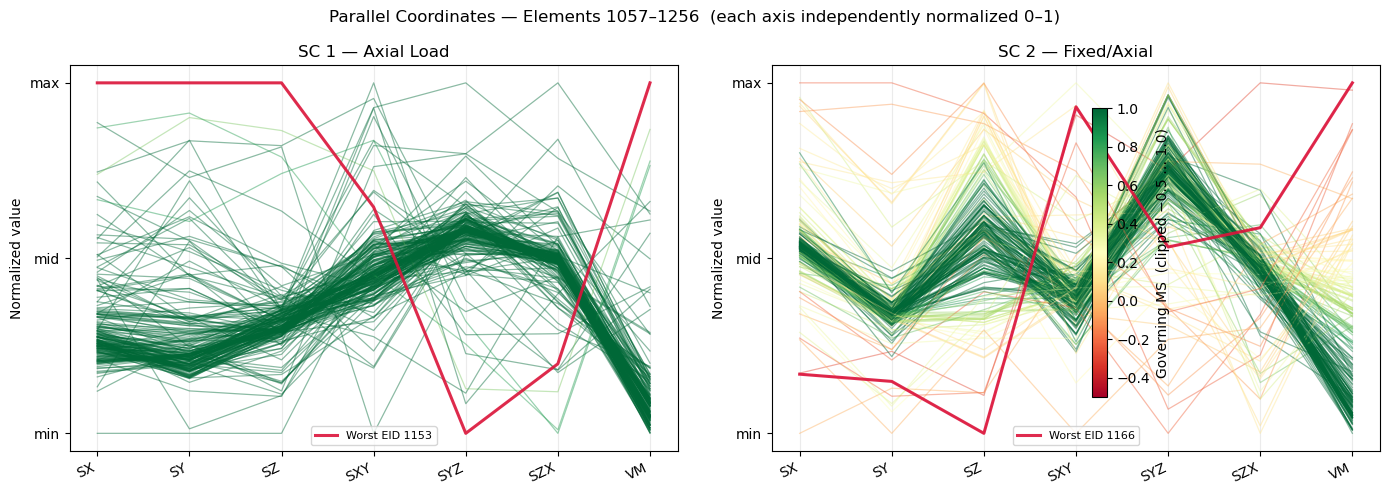

In [16]:
from matplotlib.colors import Normalize as MplNorm
from matplotlib.cm import ScalarMappable

cols_pc   = ["SX", "SY", "SZ", "SXY", "SYZ", "SZX", "VM"]
cmap_pc   = plt.cm.RdYlGn
norm_pc   = MplNorm(-0.5, 1.0)

fig_i, axes_i = plt.subplots(1, 2, figsize=(14, 5))
fig_i.suptitle(
    f"Parallel Coordinates — Elements {EID_START}–{EID_END}  "
    "(each axis independently normalized 0–1)",
    fontsize=12,
)

for ax, (sc, df) in zip(axes_i, screened.items()):
    # screened[sc] already has one row per element and all stress columns
    raw   = df[cols_pc + ["MS"]].copy()
    lo    = raw[cols_pc].min()
    hi    = raw[cols_pc].max()
    rng   = (hi - lo).replace(0, 1)
    normd = (raw[cols_pc] - lo) / rng   # 0–1 per column

    for _, row_r in normd.iterrows():
        ms_val = raw.at[row_r.name, "MS"]
        ax.plot(range(len(cols_pc)), row_r.values,
                color=cmap_pc(norm_pc(ms_val)), alpha=0.45, linewidth=0.9)

    # Highlight the worst element
    worst_row = raw["MS"].idxmin()
    ax.plot(range(len(cols_pc)), normd.loc[worst_row].values,
            color="crimson", linewidth=2.2, alpha=0.9, zorder=5,
            label=f"Worst EID {int(df.at[worst_row, 'EID'])}")

    ax.set_xticks(range(len(cols_pc)))
    ax.set_xticklabels(cols_pc, rotation=25, ha="right")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["min", "mid", "max"])
    ax.set_ylabel("Normalized value")
    ax.set_title(sc_labels.get(sc, f"SC {sc}"))
    ax.grid(axis="x", alpha=0.25)
    ax.legend(fontsize=8)

fig_i.colorbar(
    ScalarMappable(cmap=cmap_pc, norm=norm_pc),
    ax=axes_i, shrink=0.75,
    label="Governing MS  (clipped −0.5 … 1.0)",
)
plt.tight_layout()
plt.show()


### 6j · Goodman Diagram

Subcase 1 VM is treated as the **alternating stress** (σ_a) and Subcase 2 VM as the
**mean stress** (σ_m). Each element is plotted in Goodman space and coloured by its
Goodman margin of safety: MS = 1 / (σ_a/F_se + σ_m/F_tu) − 1.
Elements above the Goodman line (MS < 0) are flagged in red.
F_se is estimated as 0.5 × Fty; adjust for surface finish, Kf, notch factor, etc.


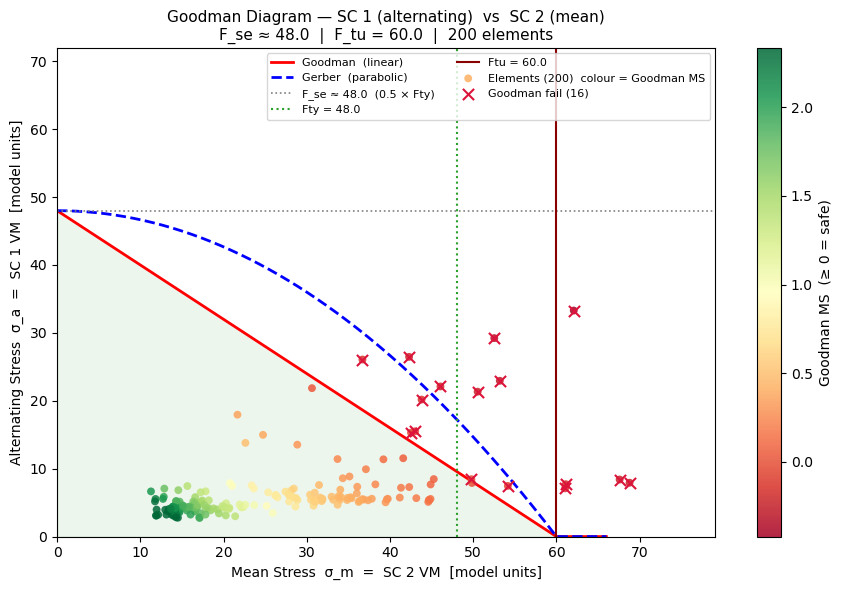

In [17]:
F_SE = 1 * F_TY          # unadjusted endurance limit estimate

sigma_m_sweep = np.linspace(0, F_TU * 1.1, 400)
goodman = np.clip(F_SE * (1 - sigma_m_sweep / F_TU), 0, None)
gerber  = np.clip(F_SE * (1 - (sigma_m_sweep / F_TU)**2), 0, None)

# ── SC 1 → alternating stress;  SC 2 → mean stress ───────────────────────────
sc_alt, sc_mean = 1, 2

df_alt  = screened[sc_alt ].set_index("EID")[["VM", "MS"]].rename(columns={"VM": "sig_a", "MS": "MS_a"})
df_mean = screened[sc_mean].set_index("EID")[["VM"]].rename(columns={"VM": "sig_m"})
gd = df_alt.join(df_mean, how="inner").reset_index()

# Goodman MS per element: MS = 1/(sig_a/F_SE + sig_m/F_TU) - 1
denom_gd = gd["sig_a"] / F_SE + gd["sig_m"] / F_TU
gd["MS_goodman"] = np.where(denom_gd > 0, 1.0 / denom_gd - 1.0, np.inf)
gd["failed_gd"]  = gd["MS_goodman"] < 0

fig_j, ax_j = plt.subplots(figsize=(9, 6))
ax_j.plot(sigma_m_sweep, goodman, "r-",  linewidth=2.0, label="Goodman  (linear)")
ax_j.plot(sigma_m_sweep, gerber,  "b--", linewidth=2.0, label="Gerber  (parabolic)")
ax_j.axhline(F_SE, color="grey",    linestyle=":", linewidth=1.2,
             label=f"F_se ≈ {F_SE:.1f}  (0.5 × Fty)")
ax_j.axvline(F_TY, color="#2ca02c", linestyle=":", linewidth=1.5,
             label=f"Fty = {F_TY:.1f}")
ax_j.axvline(F_TU, color="darkred", linestyle="-",  linewidth=1.5,
             label=f"Ftu = {F_TU:.1f}")
ax_j.fill_between(sigma_m_sweep, 0, goodman, alpha=0.07, color="green")

ms_lo  = max(gd["MS_goodman"].replace(np.inf, np.nan).min(), -1.0)
ms_hi  = min(gd["MS_goodman"].replace(np.inf, np.nan).quantile(0.95), 3.0)
cmap_j = plt.cm.RdYlGn
norm_j = MplNorm(ms_lo, ms_hi)

sc_pts = ax_j.scatter(
    gd["sig_m"], gd["sig_a"],
    c=gd["MS_goodman"].clip(ms_lo, ms_hi),
    cmap=cmap_j, norm=norm_j,
    s=32, alpha=0.85, zorder=4, linewidths=0,
    label=f"Elements ({len(gd)})  colour = Goodman MS",
)
plt.colorbar(sc_pts, ax=ax_j, label="Goodman MS  (≥ 0 = safe)")

if gd["failed_gd"].any():
    fail_gd = gd[gd["failed_gd"]]
    ax_j.scatter(fail_gd["sig_m"], fail_gd["sig_a"],
                 s=65, marker="x", color="crimson", linewidths=1.5, zorder=5,
                 label=f"Goodman fail ({len(fail_gd)})")

x_max = max(gd["sig_m"].max(), F_TU) * 1.15
y_max = max(gd["sig_a"].max() * 1.3, F_SE * 1.5)
ax_j.set_xlim(0, x_max)
ax_j.set_ylim(0, y_max)
ax_j.set_xlabel(f"Mean Stress  σ_m  =  SC {sc_mean} VM  [model units]")
ax_j.set_ylabel(f"Alternating Stress  σ_a  =  SC {sc_alt} VM  [model units]")
ax_j.set_title(
    f"Goodman Diagram — SC {sc_alt} (alternating)  vs  SC {sc_mean} (mean)\n"
    f"F_se ≈ {F_SE:.1f}  |  F_tu = {F_TU:.1f}  |  {len(gd)} elements",
    fontsize=11,
)
ax_j.legend(fontsize=8, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


### 6k · Stress Triaxiality

Triaxiality η = σ_hydrostatic / σ_VM = (σ₁+σ₂+σ₃) / (3 σ_VM). It measures how
"three-dimensional" the stress state is:

| η | State |
|---|-------|
| −⅓ | Uniaxial compression |
|  0 | Pure shear |
| +⅓ | Uniaxial tension |
| +⅔ | Biaxial tension |
| ≫ 1 | Near-hydrostatic (ductile fracture risk) |

High positive triaxiality suppresses plastic flow and increases brittle fracture risk;
the Von Mises criterion alone can be non-conservative at η > ~0.8.


C:\Users\evanc\AppData\Local\Temp\ipykernel_4332\3071640159.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


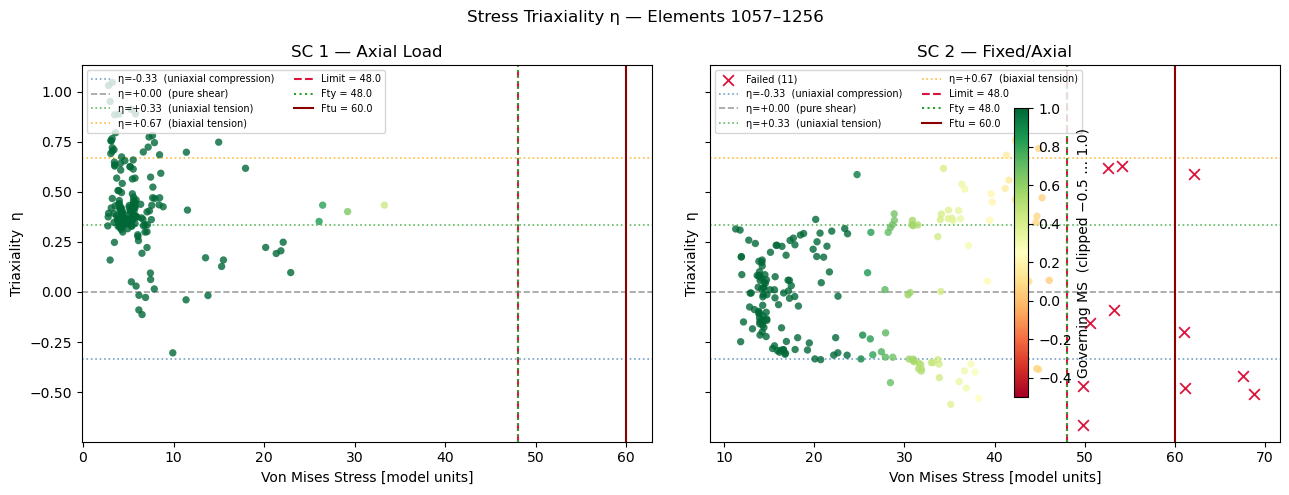

In [18]:
# ps[sc] has S1, S2, S3, VM, MS, CRITICAL (built in §6f)
triax = {
    sc: df.assign(
        ETA=((df["S1"] + df["S2"] + df["S3"]) / 3.0)
            / df["VM"].clip(lower=1e-6)
    )
    for sc, df in ps.items()
}

eta_ref = [
    (-1/3, "uniaxial compression", "steelblue", ":"),
    ( 0.0, "pure shear",           "grey",       "--"),
    ( 1/3, "uniaxial tension",     "#2ca02c",    ":"),
    ( 2/3, "biaxial tension",      "orange",     ":"),
]

fig_k, axes_k = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig_k.suptitle(
    f"Stress Triaxiality η — Elements {EID_START}–{EID_END}",
    fontsize=12,
)

for ax, (sc, tdf) in zip(axes_k, triax.items()):
    pass_t = tdf[~tdf["CRITICAL"]]
    fail_t = tdf[tdf["CRITICAL"]]

    sct_k = ax.scatter(pass_t["VM"], pass_t["ETA"],
                       c=pass_t["MS"].clip(-0.5, 1.0),
                       cmap="RdYlGn", vmin=-0.5, vmax=1.0,
                       s=28, alpha=0.80, zorder=3, linewidths=0)
    if len(fail_t):
        ax.scatter(fail_t["VM"], fail_t["ETA"],
                   s=60, marker="x", color="crimson",
                   linewidths=1.3, zorder=5, label=f"Failed ({len(fail_t)})")

    for val, lbl, col, ls in eta_ref:
        ax.axhline(val, color=col, linestyle=ls, linewidth=1.2,
                   alpha=0.75, label=f"η={val:+.2f}  ({lbl})")

    draw_allowables(ax, orientation="v")
    ax.set_xlabel("Von Mises Stress [model units]")
    ax.set_ylabel("Triaxiality  η")
    ax.set_title(sc_labels.get(sc, f"SC {sc}"))
    ax.legend(fontsize=7, ncol=2, loc="upper left")

fig_k.colorbar(
    ScalarMappable(cmap=plt.cm.RdYlGn, norm=MplNorm(-0.5, 1.0)),
    ax=axes_k, shrink=0.75, label="Governing MS  (clipped −0.5 … 1.0)",
)
plt.tight_layout()
plt.show()


### 6l · Failure Mode Map — Triaxiality vs. Lode Angle

The **Lode parameter** L = (2σ₂ − σ₁ − σ₃) / (σ₁ − σ₃) ∈ [−1, +1] describes the
deviatoric stress shape independently of triaxiality:

| L | Deviatoric state |
|---|-----------------|
| −1 | Axial tension  (σ₁ > σ₂ = σ₃) |
|  0 | Pure shear     (σ₁ = −σ₃, σ₂ = 0) |
| +1 | Axial compression (σ₁ = σ₂ > σ₃) |

Plotting η vs. L places each element in a failure-mode region — clusters reveal
dominant load-path failure mechanisms in the structure.


C:\Users\evanc\AppData\Local\Temp\ipykernel_4332\299272721.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


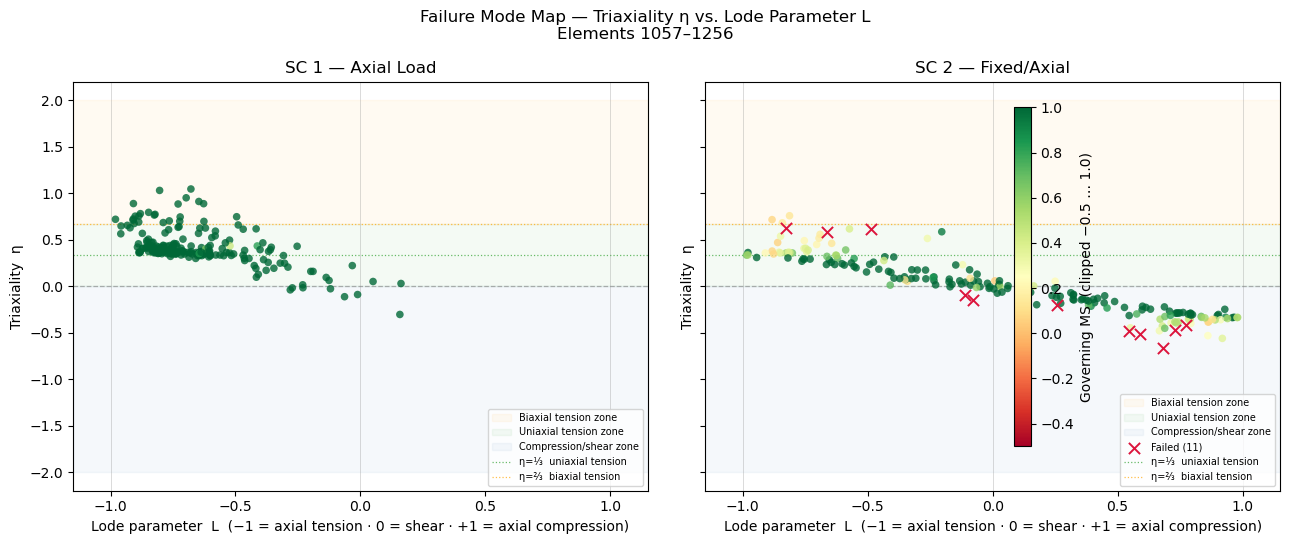

In [19]:
lode_data = {}
for sc, df in ps.items():
    denom = (df["S1"] - df["S3"]).abs().clip(lower=1e-6)
    L     = (2*df["S2"] - df["S1"] - df["S3"]) / denom
    eta   = ((df["S1"] + df["S2"] + df["S3"]) / 3.0) / df["VM"].clip(lower=1e-6)
    lode_data[sc] = df.assign(LODE=L.clip(-1, 1), ETA=eta)

# Background region shading (approximate failure mode zones)
zone_x = [-1, -1,  1,  1]
zone_y_lo = [-2, -2, -2, -2]

fig_l, axes_l = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, sharex=True)
fig_l.suptitle(
    f"Failure Mode Map — Triaxiality η vs. Lode Parameter L\n"
    f"Elements {EID_START}–{EID_END}",
    fontsize=12,
)

for ax, (sc, ldf) in zip(axes_l, lode_data.items()):
    # Zone shading
    ax.axhspan(2/3, 2.0,  alpha=0.05, color="orange",  label="Biaxial tension zone")
    ax.axhspan(0,   2/3,  alpha=0.05, color="#2ca02c", label="Uniaxial tension zone")
    ax.axhspan(-2,  0,    alpha=0.05, color="steelblue",label="Compression/shear zone")

    pass_l = ldf[~ldf["CRITICAL"]]
    fail_l = ldf[ldf["CRITICAL"]]

    ax.scatter(pass_l["LODE"], pass_l["ETA"],
               c=pass_l["MS"].clip(-0.5, 1.0),
               cmap="RdYlGn", vmin=-0.5, vmax=1.0,
               s=30, alpha=0.80, zorder=4, linewidths=0)
    if len(fail_l):
        ax.scatter(fail_l["LODE"], fail_l["ETA"],
                   s=65, marker="x", color="crimson",
                   linewidths=1.4, zorder=5, label=f"Failed ({len(fail_l)})")

    ax.axhline(0,    color="grey",   linestyle="--", linewidth=0.9, alpha=0.6)
    ax.axhline(1/3,  color="#2ca02c",linestyle=":",  linewidth=0.9, alpha=0.7,
               label="η=⅓  uniaxial tension")
    ax.axhline(2/3,  color="orange", linestyle=":",  linewidth=0.9, alpha=0.7,
               label="η=⅔  biaxial tension")
    ax.axvline(-1, color="grey", linewidth=0.5, alpha=0.4)
    ax.axvline( 1, color="grey", linewidth=0.5, alpha=0.4)
    ax.axvline( 0, color="grey", linewidth=0.5, alpha=0.4)

    ax.set_xlim(-1.15, 1.15)
    ax.set_xlabel("Lode parameter  L  (−1 = axial tension · 0 = shear · +1 = axial compression)")
    ax.set_ylabel("Triaxiality  η")
    ax.set_title(sc_labels.get(sc, f"SC {sc}"))
    ax.legend(fontsize=7, loc="lower right", ncol=1)

fig_l.colorbar(
    ScalarMappable(cmap=plt.cm.RdYlGn, norm=MplNorm(-0.5, 1.0)),
    ax=axes_l, shrink=0.80, label="Governing MS  (clipped −0.5 … 1.0)",
)
plt.tight_layout()
plt.show()


### 6m · Tornado Sensitivity

How much does the governing MS change with a ±10 % perturbation on each input
(F_TU, F_TY, RF) independently — evaluated on the **single worst element**? The longest
bars are the inputs most worth refining (tighter material test data or load precision).


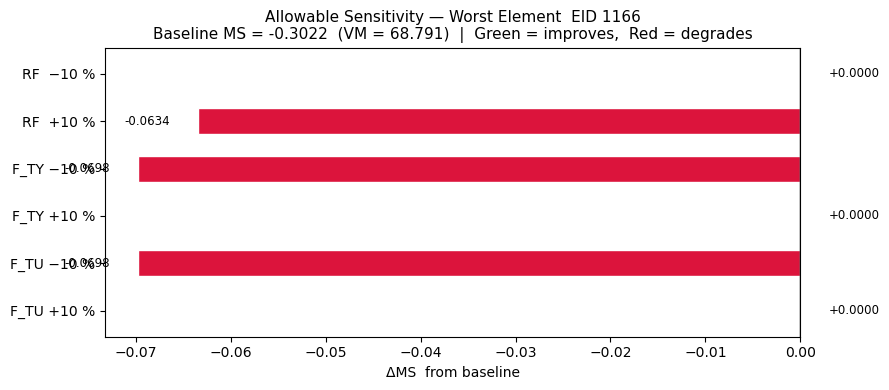

In [20]:
worst_eid_m = int(ms_waterfall.iloc[0]["EID"])
worst_vm_m  = float(envelope.set_index("EID").at[worst_eid_m, "VM"])

def _ms_governing(vm, ftu, fty, rf):
    return min(ftu / (vm * rf) - 1, fty / vm - 1)

ms_base_m = _ms_governing(worst_vm_m, F_TU, F_TY, RF)

perturbs = [
    ("F_TU +10 %",  _ms_governing(worst_vm_m, F_TU*1.1, F_TY,     RF)),
    ("F_TU −10 %",  _ms_governing(worst_vm_m, F_TU*0.9, F_TY,     RF)),
    ("F_TY +10 %",  _ms_governing(worst_vm_m, F_TU,     F_TY*1.1, RF)),
    ("F_TY −10 %",  _ms_governing(worst_vm_m, F_TU,     F_TY*0.9, RF)),
    ("RF  +10 %",   _ms_governing(worst_vm_m, F_TU,     F_TY,     RF*1.1)),
    ("RF  −10 %",   _ms_governing(worst_vm_m, F_TU,     F_TY,     RF*0.9)),
]

labels_m, ms_pert = zip(*perturbs)
delta_m = [v - ms_base_m for v in ms_pert]
col_m   = ["#55A868" if d > 0 else "crimson" for d in delta_m]

fig_m, ax_m = plt.subplots(figsize=(9, 4))
y_m = np.arange(len(labels_m))
ax_m.barh(y_m, delta_m, color=col_m, height=0.55, edgecolor="white")
ax_m.axvline(0, color="black", linewidth=1.0, zorder=3)

for i, d in enumerate(delta_m):
    ax_m.text(d + (0.003 if d >= 0 else -0.003), i, f"{d:+.4f}",
              va="center", ha="left" if d >= 0 else "right", fontsize=8.5)

ax_m.set_yticks(y_m)
ax_m.set_yticklabels(labels_m)
ax_m.set_xlabel("ΔMS  from baseline")
ax_m.set_title(
    f"Allowable Sensitivity — Worst Element  EID {worst_eid_m}\n"
    f"Baseline MS = {ms_base_m:.4f}  (VM = {worst_vm_m:.3f})  |  "
    "Green = improves,  Red = degrades",
    fontsize=11,
)
plt.tight_layout()
plt.show()


### 6n · Reserve Factor Contour

MS of the worst element as a 2-D function of (F_TU, RF). The MS = 0 contour is the
design boundary — the white star marks the current design point. Use this to answer
*"how much margin do I buy with a 5 % allowable increase?"* or
*"what RF reduction keeps me in the black?"*.


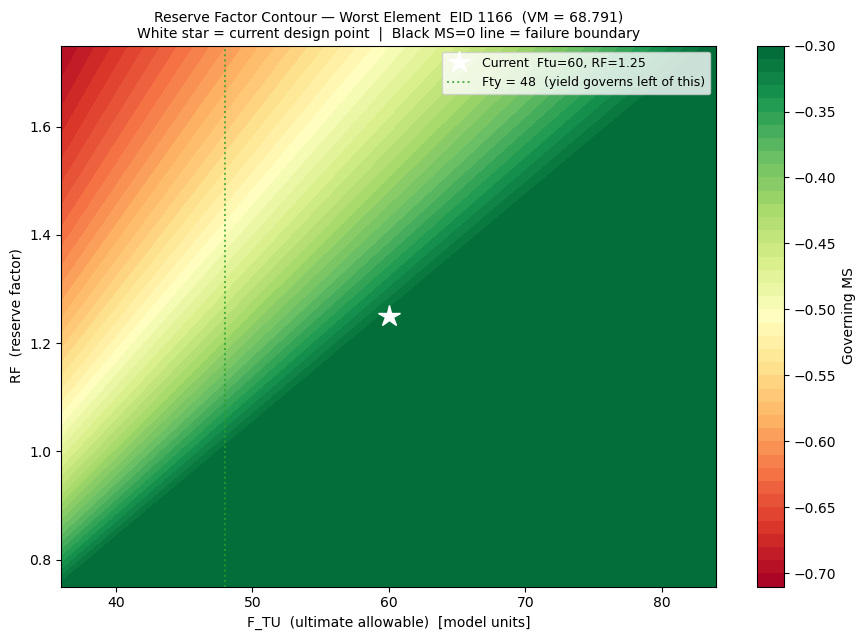

In [21]:
ftu_sweep = np.linspace(F_TU * 0.60, F_TU * 1.40, 120)
rf_sweep  = np.linspace(RF  * 0.60, RF  * 1.40, 120)
FTU_G, RF_G = np.meshgrid(ftu_sweep, rf_sweep)

MS_ULT_G   = FTU_G / (worst_vm_m * RF_G) - 1.0
MS_YIELD_G  = F_TY / worst_vm_m - 1.0           # RF only affects ult check
MS_MAP_G    = np.minimum(MS_ULT_G, MS_YIELD_G)

fig_n, ax_n = plt.subplots(figsize=(9, 6.5))
cf_n = ax_n.contourf(FTU_G, RF_G, MS_MAP_G, levels=40, cmap="RdYlGn")
cs_n = ax_n.contour(FTU_G, RF_G, MS_MAP_G,
                     levels=[-0.2, -0.1, 0.0, 0.1, 0.2, 0.5],
                     colors="black", linewidths=[0.8, 0.8, 2.0, 0.8, 0.8, 0.8])
ax_n.clabel(cs_n, fmt=lambda v: f"MS={v:+.1f}", fontsize=8)

ax_n.plot(F_TU, RF, "w*", markersize=16, zorder=5,
          label=f"Current  Ftu={F_TU:.0f}, RF={RF:.2f}")
ax_n.axvline(F_TY, color="#2ca02c", linestyle=":", linewidth=1.4, alpha=0.8,
             label=f"Fty = {F_TY:.0f}  (yield governs left of this)")

plt.colorbar(cf_n, ax=ax_n, label="Governing MS")
ax_n.set_xlabel("F_TU  (ultimate allowable)  [model units]")
ax_n.set_ylabel("RF  (reserve factor)")
ax_n.set_title(
    f"Reserve Factor Contour — Worst Element  EID {worst_eid_m}  "
    f"(VM = {worst_vm_m:.3f})\n"
    "White star = current design point  |  Black MS=0 line = failure boundary",
    fontsize=10,
)
ax_n.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 6o · Stress Gradient Flag

For each CTETRA element, the **VM spread** = (max − min) / mean across its 4 integration
nodes measures how unevenly stress varies within the element. A high spread (> ~25 %)
suggests a steep stress gradient that the mesh may not be resolving accurately — these
elements are candidates for local mesh refinement rather than definitive failures.


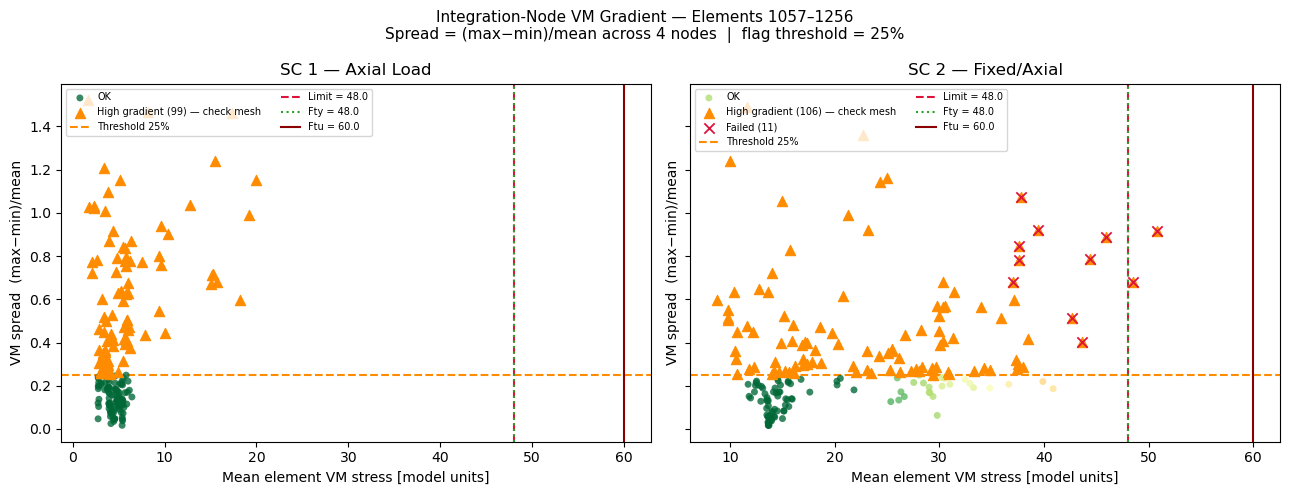

In [22]:
GRAD_THRESH = 0.25   # 25 % spread → flag for mesh review

grad_data = {
    sc: (
        subsets[sc]
        .groupby("EID")["VM"]
        .agg(vm_mx="max", vm_mn="min", vm_mean="mean")
        .assign(spread=lambda g: (g["vm_mx"] - g["vm_mn"]) / g["vm_mean"].clip(lower=1e-6))
        .reset_index()
        .merge(screened[sc][["EID", "MS", "CRITICAL"]], on="EID", how="left")
    )
    for sc in sorted(subsets)
}

fig_o, axes_o = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig_o.suptitle(
    f"Integration-Node VM Gradient — Elements {EID_START}–{EID_END}\n"
    f"Spread = (max−min)/mean across 4 nodes  |  flag threshold = {GRAD_THRESH:.0%}",
    fontsize=11,
)

for ax, (sc, gdf) in zip(axes_o, grad_data.items()):
    flagged = gdf["spread"] > GRAD_THRESH

    ax.scatter(gdf.loc[~flagged, "vm_mean"], gdf.loc[~flagged, "spread"],
               c=gdf.loc[~flagged, "MS"].clip(-0.5, 1.0),
               cmap="RdYlGn", vmin=-0.5, vmax=1.0,
               s=25, alpha=0.78, zorder=3, linewidths=0, label="OK")
    if flagged.any():
        ax.scatter(gdf.loc[flagged, "vm_mean"], gdf.loc[flagged, "spread"],
                   s=55, marker="^", color="darkorange", linewidths=0.8,
                   zorder=5, label=f"High gradient ({flagged.sum()}) — check mesh")

    fail_flag = gdf["CRITICAL"]
    if fail_flag.any():
        ax.scatter(gdf.loc[fail_flag, "vm_mean"], gdf.loc[fail_flag, "spread"],
                   s=55, marker="x", color="crimson", linewidths=1.3,
                   zorder=6, label=f"Failed ({fail_flag.sum()})")

    ax.axhline(GRAD_THRESH, color="darkorange", linestyle="--",
               linewidth=1.5, label=f"Threshold {GRAD_THRESH:.0%}")
    draw_allowables(ax, orientation="v")
    ax.set_xlabel("Mean element VM stress [model units]")
    ax.set_ylabel("VM spread  (max−min)/mean")
    ax.set_title(sc_labels.get(sc, f"SC {sc}"))
    ax.legend(fontsize=7, loc="upper left", ncol=2)

plt.tight_layout()
plt.show()


### 6p · Subcase Contribution

For each of the 20 highest-VM elements, grouped bars show the VM in every subcase
side-by-side so you can see exactly which subcase is driving each element.
A pie chart summarises what fraction of all elements in the set are governed by each subcase.


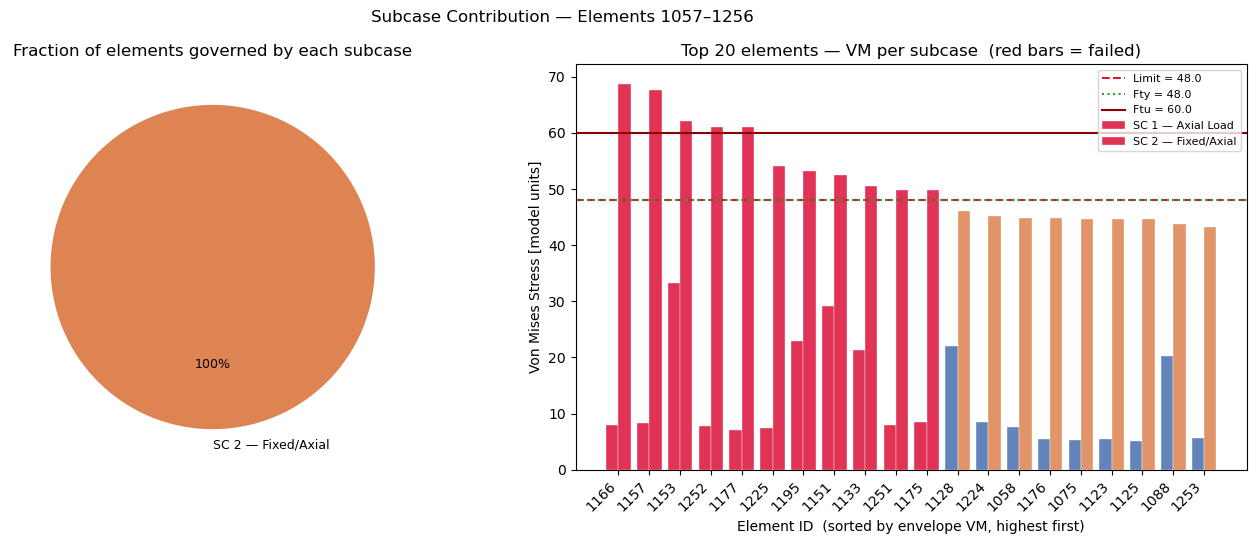

In [23]:
sc_keys = sorted(screened)
sc_cols = [f"SC{sc}" for sc in sc_keys]

sc_vm_df = pd.DataFrame({
    f"SC{sc}": screened[sc].set_index("EID")["VM"]
    for sc in sc_keys
})
sc_vm_df["max_vm"]       = sc_vm_df[sc_cols].max(axis=1)
sc_vm_df["governing_sc"] = sc_vm_df[sc_cols].idxmax(axis=1)
sc_vm_df = sc_vm_df.reset_index()   # EID becomes column

crit_map = envelope.set_index("EID")["CRITICAL"]
sc_vm_df["CRITICAL"] = sc_vm_df["EID"].map(crit_map)

gov_counts = sc_vm_df["governing_sc"].value_counts().sort_index()

n_show = min(20, len(sc_vm_df))
top_df = sc_vm_df.nlargest(n_show, "max_vm").reset_index(drop=True)

fig_p, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(14, 5.5))
fig_p.suptitle(f"Subcase Contribution — Elements {EID_START}–{EID_END}", fontsize=12)

pal_pie = [colors.get(int(s.replace("SC", "")), "#aaa") for s in gov_counts.index]
ax_pie.pie(
    gov_counts.values,
    labels=[sc_labels.get(int(s.replace("SC", "")), s) for s in gov_counts.index],
    autopct="%1.0f%%", colors=pal_pie, startangle=90,
    textprops={"fontsize": 9},
)
ax_pie.set_title("Fraction of elements governed by each subcase")

x_b  = np.arange(n_show)
ww_b = 0.80 / len(sc_keys)

for i, sc in enumerate(sc_keys):
    col = f"SC{sc}"
    bar_c = [
        "crimson" if top_df.loc[j, "CRITICAL"] else colors.get(sc, "#888")
        for j in range(n_show)
    ]
    ax_bar.bar(
        x_b + (i - (len(sc_keys) - 1) / 2) * ww_b,
        top_df[col], width=ww_b,
        color=bar_c, label=sc_labels.get(sc, f"SC {sc}"),
        edgecolor="white", linewidth=0.3, zorder=2, alpha=0.87,
    )

draw_allowables(ax_bar, orientation="h")
ax_bar.set_xticks(x_b)
ax_bar.set_xticklabels(top_df["EID"].astype(str).tolist(), rotation=45, ha="right")
ax_bar.set_xlabel("Element ID  (sorted by envelope VM, highest first)")
ax_bar.set_ylabel("Von Mises Stress [model units]")
ax_bar.set_title(f"Top {n_show} elements — VM per subcase  (red bars = failed)")
ax_bar.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 7 · Summary Report


In [ ]:
report = (
    envelope[["EID", "SC", "GRID", "VM", "VM_factored", "MS", "CRITICAL"]]
    .rename(columns={
        "EID":         "Element ID",
        "SC":          "Worst SC",
        "GRID":        "Grid (max node)",
        "VM":          "VM Stress",
        "VM_factored": f"VM × {RF:.2f}",
        "MS":          "Margin of Safety",
        "CRITICAL":    "Failed?",
    })
    .sort_values("Margin of Safety")
    .reset_index(drop=True)
)

print(f"─── Strength Screening Summary ─────────────────────────────────")
print(f"  OP2              : {OP2_FILE.name}")
print(f"  Elements checked : {len(report)}")
print(f"  Allowable (Ftu)  : {F_TU}")
print(f"  Reserve factor   : {RF}")
print(f"  Elements failed  : {int(report['Failed?'].sum())}")
print(f"  Min MS           : {report['Margin of Safety'].min():.4f}")
print(f"  Max MS           : {report['Margin of Safety'].max():.4f}")
print(f"────────────────────────────────────────────────────────────────")
print("\nWorst 10 elements:")
report.head(10)


─── Strength Screening Summary ─────────────────────────────────
  OP2              : cylinder-0001.op2
  Elements checked : 200
  Allowable (Ftu)  : 60.0
  Reserve factor   : 1.25
  Elements failed  : 11
  Min MS           : -0.3022
  Max MS           : 3.2575
────────────────────────────────────────────────────────────────

Worst 10 elements:


,Element ID,Worst SC,Grid (max node),VM Stress,VM × 1.25,Margin of Safety,Failed?
0,1166,2,33,68.79,85.99,-0.3022,True
1,1157,2,415,67.59,84.49,-0.2899,True
2,1153,2,346,62.08,77.6,-0.2268,True
3,1252,2,34,61.13,76.42,-0.2148,True
4,1177,2,32,61.05,76.31,-0.2137,True
5,1225,2,430,54.16,67.7,-0.1138,True
6,1195,2,449,53.19,66.49,-0.09765,True
7,1151,2,346,52.53,65.66,-0.08627,True
8,1133,2,449,50.53,63.16,-0.0501,True
9,1251,2,414,49.85,62.32,-0.03717,True


: 